# 🔍 Agrupamento de Clientes (Clustering)
## Dataset: *Default of Credit Card Clients*
---
**Disciplina:** Tópicos em Engenharia de Computação  
**Dataset:** Default of Credit Card Clients – UCI Machine Learning Repository  
**Objetivo:** Identificar grupos homogêneos de clientes por meio de técnicas de agrupamento não supervisionado (K-Means e Clusterização Hierárquica), revelando perfis de comportamento financeiro.

> **Fonte:** Yeh, I. C., & Lien, C. H. (2009). *The comparisons of data mining techniques for the predictive accuracy of probability of default of credit card clients.* Expert Systems with Applications.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import cdist

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

print("Bibliotecas importadas com sucesso!")


Bibliotecas importadas com sucesso!


In [2]:
URL = (
    "https://archive.ics.uci.edu/ml/machine-learning-databases/"
    "00350/default%20of%20credit%20card%20clients.xls"
)

df_raw = pd.read_excel(URL, header=1)
print(f"Dataset carregado: {df_raw.shape[0]:,} registros × {df_raw.shape[1]} variáveis")


Dataset carregado: 30,000 registros × 25 variáveis


In [3]:
# ── Renomeação das colunas ────────────────────────────────────────────────
df = df_raw.copy()
mapa_colunas = {
    'ID': 'id', 'LIMIT_BAL': 'limite_credito',
    'SEX': 'sexo', 'EDUCATION': 'escolaridade', 'MARRIAGE': 'estado_civil',
    'AGE': 'idade',
    'PAY_0': 'status_pag_set', 'PAY_2': 'status_pag_ago',
    'PAY_3': 'status_pag_jul', 'PAY_4': 'status_pag_jun',
    'PAY_5': 'status_pag_mai', 'PAY_6': 'status_pag_abr',
    'BILL_AMT1': 'fatura_set', 'BILL_AMT2': 'fatura_ago',
    'BILL_AMT3': 'fatura_jul', 'BILL_AMT4': 'fatura_jun',
    'BILL_AMT5': 'fatura_mai', 'BILL_AMT6': 'fatura_abr',
    'PAY_AMT1': 'pagamento_set', 'PAY_AMT2': 'pagamento_ago',
    'PAY_AMT3': 'pagamento_jul', 'PAY_AMT4': 'pagamento_jun',
    'PAY_AMT5': 'pagamento_mai', 'PAY_AMT6': 'pagamento_abr',
    'default payment next month': 'inadimplente',
}
df.rename(columns=mapa_colunas, inplace=True)

# ── Limpeza ───────────────────────────────────────────────────────────────
df.drop(columns=['id'], inplace=True)
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

# ── Mapeamento categórico ─────────────────────────────────────────────────
df['sexo']         = df['sexo'].map({1: 'Masculino', 2: 'Feminino'})
df['escolaridade'] = df['escolaridade'].map(
    {0:'Outros', 1:'Pós-graduação', 2:'Graduação', 3:'Ensino Médio',
     4:'Outros', 5:'Outros', 6:'Outros'})
df['estado_civil'] = df['estado_civil'].map(
    {0:'Outros', 1:'Casado', 2:'Solteiro', 3:'Outros'})
df['inadimplente'] = df['inadimplente'].astype(int)

# ── Feature engineering ──────────────────────────────────────────────────
cols_fatura    = ['fatura_set','fatura_ago','fatura_jul','fatura_jun','fatura_mai','fatura_abr']
cols_pagamento = ['pagamento_set','pagamento_ago','pagamento_jul','pagamento_jun','pagamento_mai','pagamento_abr']
cols_status    = ['status_pag_set','status_pag_ago','status_pag_jul','status_pag_jun','status_pag_mai','status_pag_abr']

df['media_fatura']    = df[cols_fatura].mean(axis=1).round(2)
df['media_pagamento'] = df[cols_pagamento].mean(axis=1).round(2)
df['taxa_utilizacao'] = np.clip(
    np.where(df['limite_credito'] > 0, df['media_fatura'] / df['limite_credito'], 0), 0, 1.0
).round(4)
df['qtd_atrasos'] = (df[cols_status] >= 1).sum(axis=1)

bins, labels = [0,25,35,45,55,100], ['Até 25','26–35','36–45','46–55','Acima de 55']
df['faixa_etaria'] = pd.cut(df['idade'], bins=bins, labels=labels, right=True)

def classificar_risco(row):
    if row['taxa_utilizacao'] >= 0.8 or row['qtd_atrasos'] >= 3:
        return 'Alto'
    elif row['taxa_utilizacao'] >= 0.5 or row['qtd_atrasos'] >= 1:
        return 'Médio'
    return 'Baixo'
df['perfil_risco'] = df.apply(classificar_risco, axis=1)

print(f"Pré-processamento concluído!  Shape: {df.shape}")
print(df.head(3).to_string())


Pré-processamento concluído!  Shape: (29965, 30)
   limite_credito      sexo escolaridade estado_civil  idade  status_pag_set  status_pag_ago  status_pag_jul  status_pag_jun  status_pag_mai  status_pag_abr  fatura_set  fatura_ago  fatura_jul  fatura_jun  fatura_mai  fatura_abr  pagamento_set  pagamento_ago  pagamento_jul  pagamento_jun  pagamento_mai  pagamento_abr  inadimplente  media_fatura  media_pagamento  taxa_utilizacao  qtd_atrasos faixa_etaria perfil_risco
0           20000  Feminino    Graduação       Casado     24               2               2              -1              -1              -2              -2        3913        3102         689           0           0           0              0            689              0              0              0              0             1     1284.0000         114.8300           0.0642            2       Até 25        Médio
1          120000  Feminino    Graduação     Solteiro     26              -1               2               0   

In [4]:
# Variáveis selecionadas para o agrupamento
features = [
    'limite_credito',
    'idade',
    'media_fatura',
    'media_pagamento',
    'taxa_utilizacao',
    'qtd_atrasos',
]

X = df[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

print("Variáveis selecionadas para clustering:")
for f in features:
    print(f"   • {f}")
print(f"\nShape da matriz normalizada: {X_scaled.shape}")
print("\nEstatísticas após padronização:")
display(X_scaled_df.describe().round(4))


Variáveis selecionadas para clustering:
   • limite_credito
   • idade
   • media_fatura
   • media_pagamento
   • taxa_utilizacao
   • qtd_atrasos

Shape da matriz normalizada: (29965, 6)

Estatísticas após padronização:


,limite_credito,idade,media_fatura,media_pagamento,taxa_utilizacao,qtd_atrasos
count,29965.0000,29965.0000,29965.0000,29965.0000,29965.0000,29965.0000
mean,-0.0000,0.0000,-0.0000,0.0000,0.0000,-0.0000
std,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
min,-1.2134,-1.5715,-1.5973,-0.5207,-1.0801,-0.5366
25%,-0.9051,-0.8122,-0.6351,-0.4106,-0.9918,-0.5366
50%,-0.2115,-0.1614,-0.3780,-0.2841,-0.2480,-0.5366
75%,0.5592,0.5979,0.1918,0.0314,0.9260,0.1066
max,6.4162,4.7197,13.1528,61.3345,1.8336,3.3224


In [5]:
K_RANGE = range(2, 11)
inercias = []
silhuetas = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels_k = km.fit_predict(X_scaled)
    inercias.append(km.inertia_)
    silhuetas.append(silhouette_score(X_scaled, labels_k))

print("k | Inércia        | Silhueta")
print("-" * 40)
for k, in_, sil in zip(K_RANGE, inercias, silhuetas):
    print(f"{k:2d} | {in_:>14,.1f} | {sil:.4f}")


k | Inércia        | Silhueta
----------------------------------------
 2 |      141,820.3 | 0.2551
 3 |      116,000.2 | 0.2686
 4 |       98,318.5 | 0.2729
 5 |       87,647.0 | 0.2304
 6 |       77,278.8 | 0.2698
 7 |       68,299.0 | 0.2584
 8 |       63,466.6 | 0.2579
 9 |       58,855.2 | 0.2593
10 |       55,103.4 | 0.2605


### 📈 Gráfico 4.1 — Cotovelo e Coeficiente de Silhueta

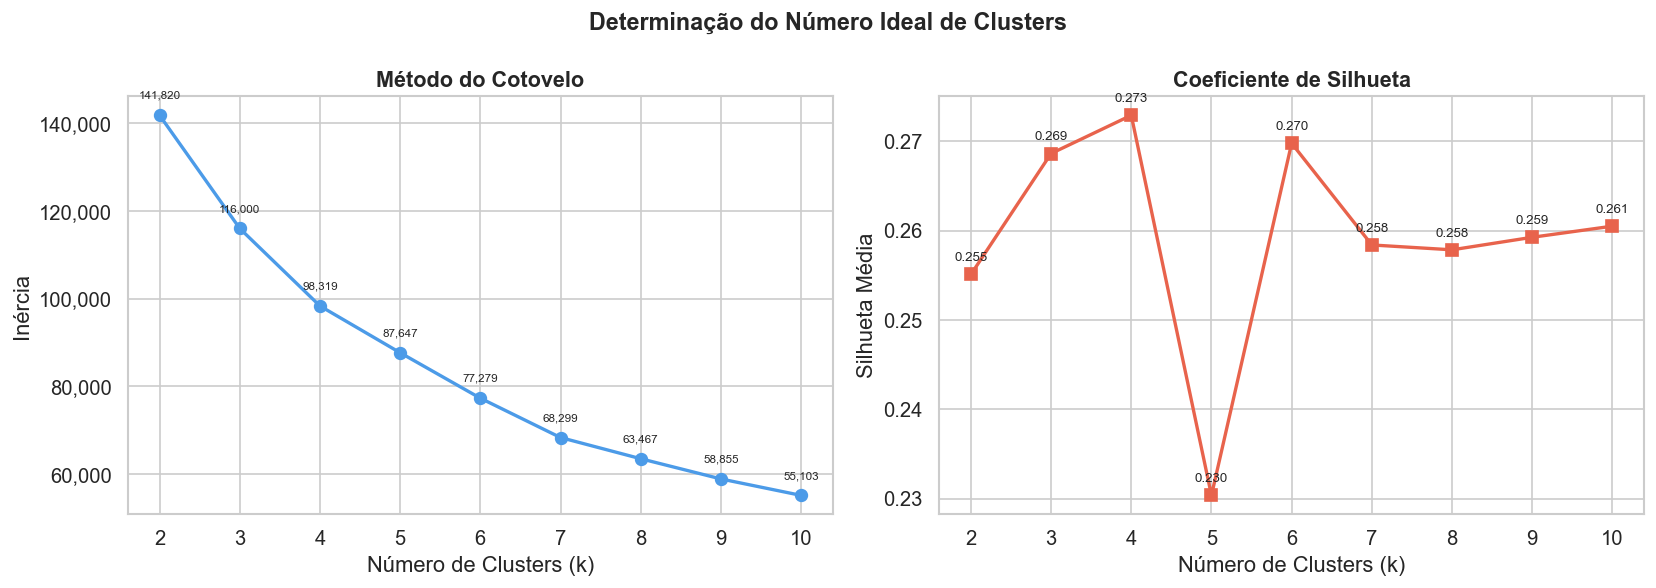

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ks = list(K_RANGE)

# Cotovelo
axes[0].plot(ks, inercias, 'o-', color='#4C9BE8', linewidth=2, markersize=7)
axes[0].set_title('Método do Cotovelo')
axes[0].set_xlabel('Número de Clusters (k)')
axes[0].set_ylabel('Inércia')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
for x, y in zip(ks, inercias):
    axes[0].annotate(f'{y:,.0f}', (x, y), textcoords='offset points',
                     xytext=(0, 10), ha='center', fontsize=7)

# Silhueta
axes[1].plot(ks, silhuetas, 's-', color='#E8634C', linewidth=2, markersize=7)
axes[1].set_title('Coeficiente de Silhueta')
axes[1].set_xlabel('Número de Clusters (k)')
axes[1].set_ylabel('Silhueta Média')
for x, y in zip(ks, silhuetas):
    axes[1].annotate(f'{y:.3f}', (x, y), textcoords='offset points',
                     xytext=(0, 8), ha='center', fontsize=8)

plt.suptitle('Determinação do Número Ideal de Clusters', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 5. K-Means com k Ótimo
Treinamento do modelo K-Means com o número de clusters escolhido a partir da análise anterior.


In [7]:
K_OTIMO = 4   # ajuste conforme o cotovelo/silhueta observados

km_final = KMeans(n_clusters=K_OTIMO, init='k-means++', n_init=20, random_state=42)
df['cluster_kmeans'] = km_final.fit_predict(X_scaled)

sil_final = silhouette_score(X_scaled, df['cluster_kmeans'])
print(f"K-Means treinado com k={K_OTIMO}")
print(f"Inércia final    : {km_final.inertia_:,.2f}")
print(f"Silhueta média   : {sil_final:.4f}")
print("\nDistribuição dos clusters:")
display(df['cluster_kmeans'].value_counts().sort_index().rename('Clientes'))


K-Means treinado com k=4
Inércia final    : 98,318.42
Silhueta média   : 0.2731

Distribuição dos clusters:


cluster_kmeans
0     9516
1    14043
2     2979
3     3427
Name: Clientes, dtype: int64

### 8.2 Treinamento do Agglomerative Clustering

In [8]:
agg = AgglomerativeClustering(n_clusters=K_OTIMO, linkage='ward')
df['cluster_hierarquico'] = agg.fit_predict(X_scaled)

sil_agg = silhouette_score(X_scaled, df['cluster_hierarquico'])
print(f"Agglomerative Clustering — k={K_OTIMO}")
print(f"Silhueta média: {sil_agg:.4f}")
print("\nDistribuição:")
display(df['cluster_hierarquico'].value_counts().sort_index().rename('Clientes'))


Agglomerative Clustering — k=4
Silhueta média: 0.2294

Distribuição:


cluster_hierarquico
0     4907
1    15123
2     6874
3     3061
Name: Clientes, dtype: int64